In [1]:
import numpy as np
import healpy as hp
import pysm3 as sm

import matplotlib as mpl
import matplotlib.pyplot as plt

import cmasher as cmr
import seaborn as sns

import sys
sys.path.append('../')

from src.utils import pretty_axes, modify_rc
modify_rc()
modify_rc()
from src import synthesize


In [28]:
NSIDE = 512
LMAX = 3*NSIDE - 1

ells = np.arange(LMAX+1)
alpha = 8./3.
L = 10.
target_cl = np.sqrt(ells**2 + L**2)**(-alpha)
target_cl[np.isnan(target_cl)|np.isinf(target_cl)] = 1e-15

t_delta_params = {
    'cl_target': target_cl,
    'cl_noise': target_cl,
    'c':5.0,
    'lambda':0.25,
    'anisotropy':'isotropic',
}
e_delta_params = {
    'cl_target': target_cl,
    'cl_noise':target_cl,
    'c':5.0,
    'lambda':0.25,
    'anisotropy':'isotropic',
}
b_delta_params = {
    'cl_target':target_cl,
    'cl_noise':target_cl,
    'c':5.0,
    'lambda':0.25,
    'anisotropy':'isotropic',
}

cl_tt, cl_ee, cl_bb, cl_te = 1.*target_cl, 0.75*target_cl, 0.2*target_cl, 0.3*target_cl

i_delta, q_delta, u_delta = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
t_delta, e_delta, b_delta = hp.alm2map(hp.map2alm([i_delta, q_delta, u_delta], pol=True), NSIDE, pol=False)

Text(0.5, 1.0, '$\\xi_\\delta = \\sqrt{q_\\delta^2 + u_\\delta^2}$')

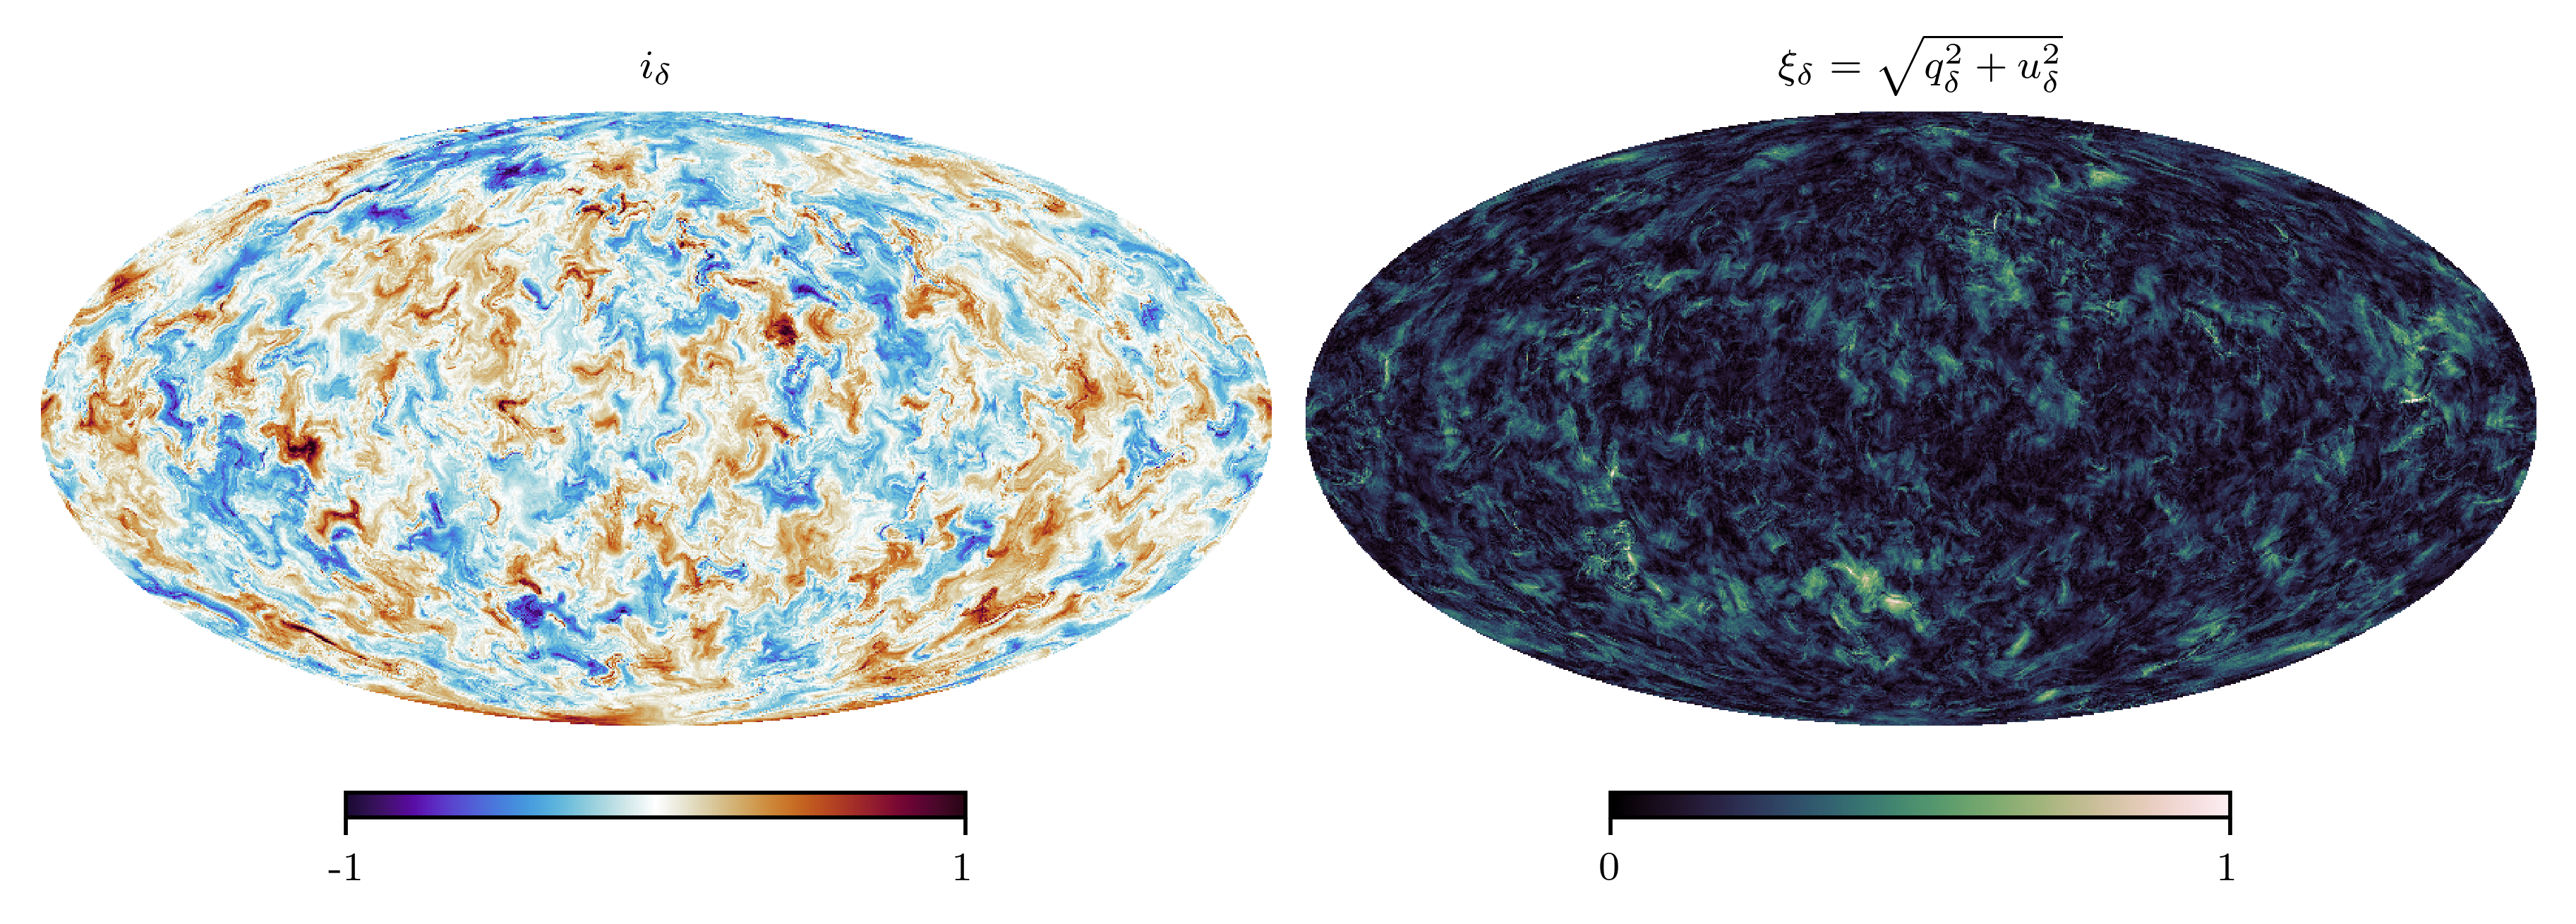

In [33]:
fig = plt.figure(figsize=(7., 3.5), dpi=512)

fusion_cmap = cmr.fusion_r
fusion_cmap.set_under('w')

pol_cmap = sns.cubehelix_palette(start=0.5, rot=-0.95, dark=0.0, light=0.95, as_cmap=True, reverse=True)
pol_cmap.set_under('w')

hp.mollview(i_delta, cmap=fusion_cmap, min=-1., max=1., fig=fig, sub=(1, 2, 1), title='')
ax = plt.gca()
ax.set_title(r'$i_\delta$', fontsize=8.)
hp.mollview(np.sqrt(q_delta**2 + u_delta**2), cmap=pol_cmap, min=0., max=1., fig=fig, sub=(1, 2, 2), title='')
ax = plt.gca()
ax.set_title(r'$\xi_\delta = \sqrt{q_\delta^2 + u_\delta^2}$', fontsize=8.)


Text(0.5, 1.0, '$b_\\delta$')

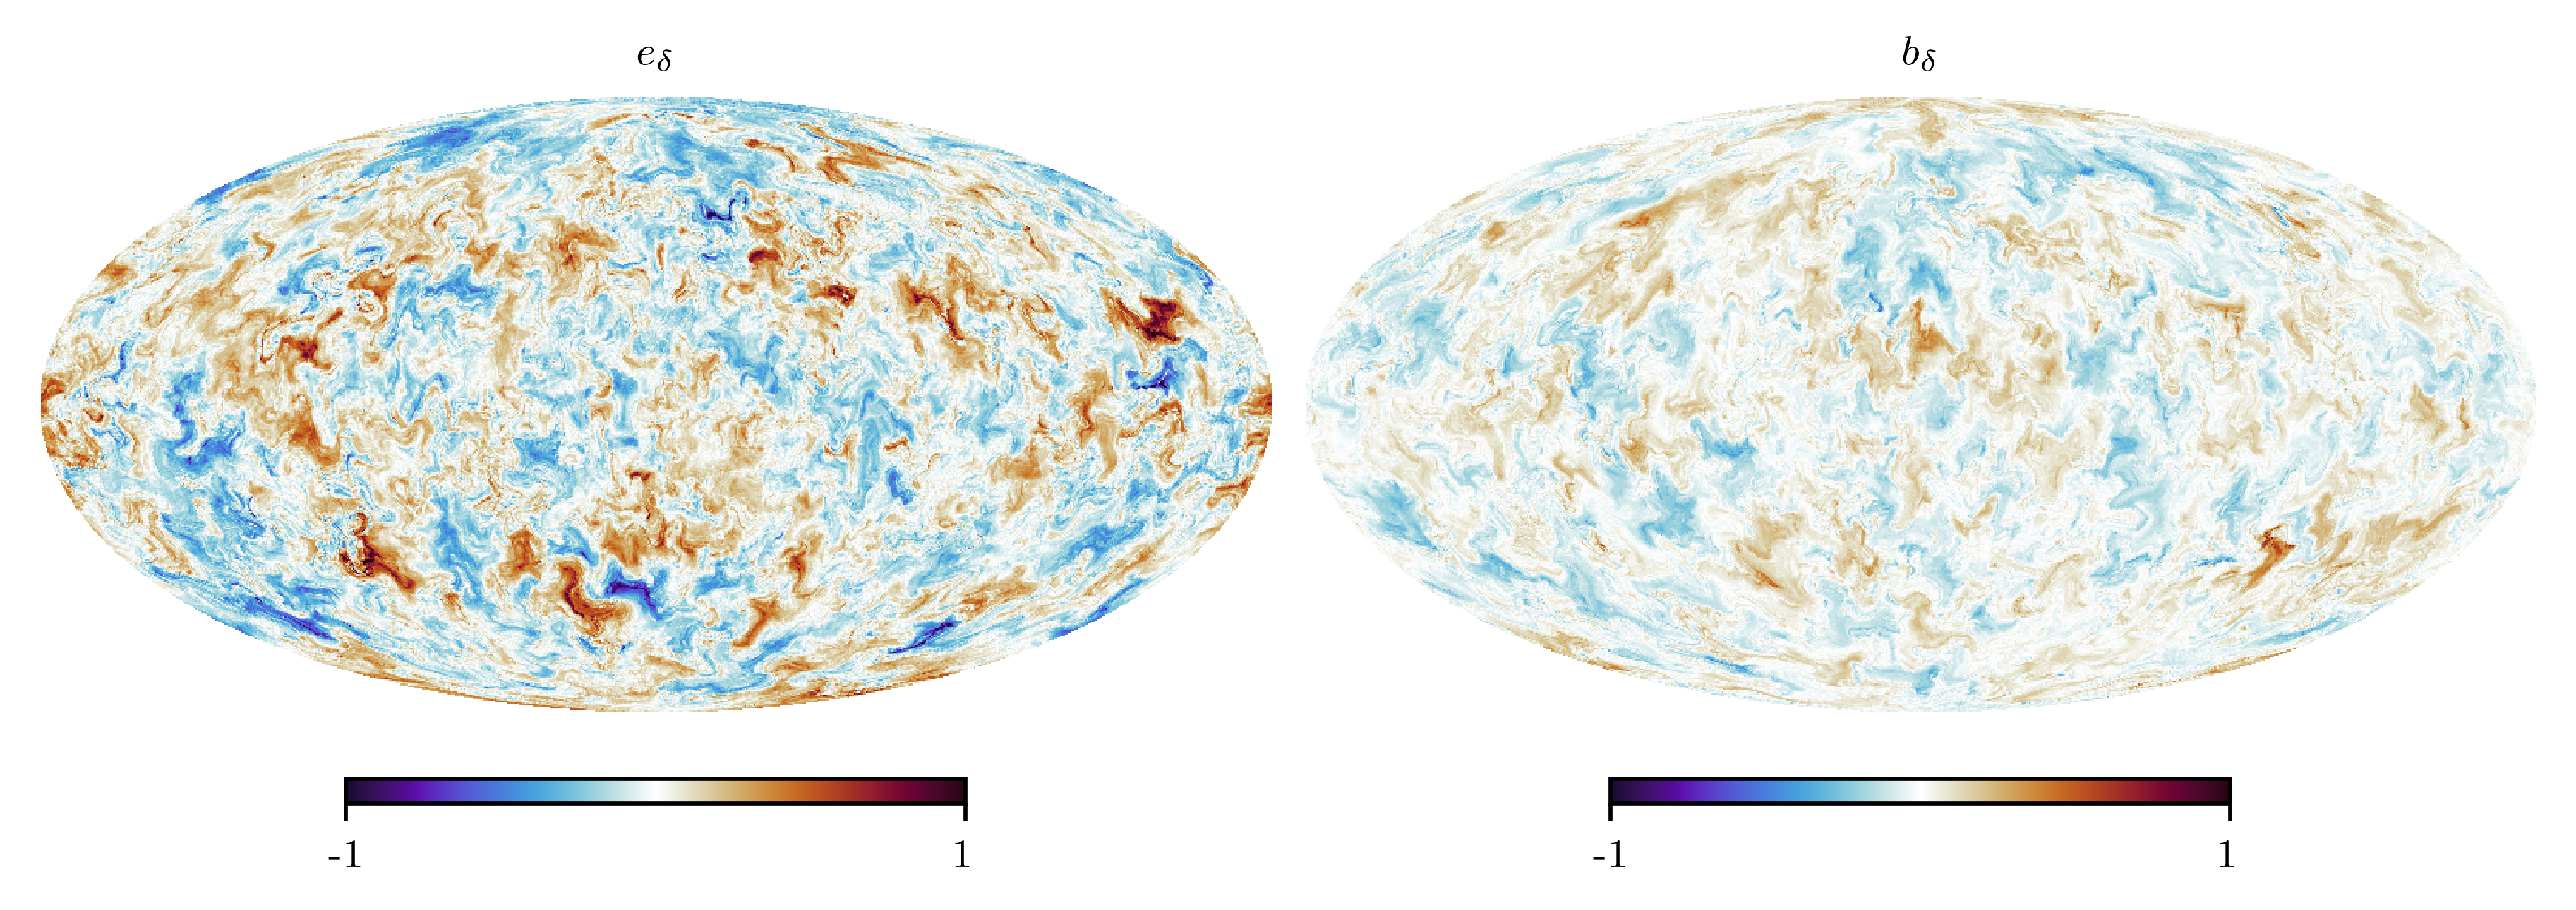

In [35]:
fig = plt.figure(figsize=(7., 3.5), dpi=512)

fusion_cmap = cmr.fusion_r
fusion_cmap.set_under('w')

pol_cmap = sns.cubehelix_palette(start=0.5, rot=-0.95, dark=0.0, light=0.95, as_cmap=True, reverse=True)
pol_cmap.set_under('w')

hp.mollview(e_delta, cmap=fusion_cmap, min=-1., max=1., fig=fig, sub=(1, 2, 1), title='')
ax = plt.gca()
ax.set_title(r'$e_\delta$', fontsize=8.)
hp.mollview(b_delta, cmap=fusion_cmap, min=-1., max=1., fig=fig, sub=(1, 2, 2), title='')
ax = plt.gca()
ax.set_title(r'$b_\delta$', fontsize=8.)
